Statistical Power and Minimum Detectable Effect (MDE)

Statistical power is the probability that a test will correctly detect a real effect when one exists.
MDE (Minimum Detectable Effect) is the smallest effect size a test can reliably detect given a fixed sample size and significance level.

Two key factors control test power:

Sample size — more data = more power
Effect size — larger differences are easier to detect
We simulate A/B tests using a t-test to observe how power changes across these dimensions.

In [1]:
from scipy import stats
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


Part 1: Sample Size vs. Power (small effect = 1%)

We fix a tiny effect (1% difference in means) and vary the sample size.
For each configuration, we run 1 000 simulated A/B tests and measure how often we correctly detect the difference (p < 0.05).

In [8]:
x = 100
sigma = 10
sizes = [10, 100, 1000]


diff = 0.01
alpha = 0.05

n_trials = 1000

powers_size = []

for size in sizes:
    significant_count = 0
    for _ in range(n_trials):

        control = np.random.normal(x, sigma, size)
        treatment = np.random.normal(x*(1+diff), sigma, size)
        experiment = stats.ttest_ind(control, treatment)

        if experiment.pvalue < alpha:
            significant_count+=1
            
    power = significant_count/n_trials
    powers_size.append(power)
    print(f"n={size} → power = {power:.3f}")



n=10 → power = 0.052
n=100 → power = 0.107
n=1000 → power = 0.614


Part 2: Effect Size vs. Power (fixed sample sizes)

Now we increase the effect to 10% and see how even small samples start detecting it reliably.

In [17]:
x = 100
sigma = 10
n = 30

diffs = [0.05, 0.1, 0.3]

powers_diff = []

for d in diffs:
    significant_count = 0
    for _ in range(n_trials):
        control = np.random.normal(x, sigma, n)
        experiment = np.random.normal(x*(1+d), sigma, n)
        pvalue = stats.ttest_ind(control, experiment).pvalue
        
        if pvalue < alpha:
            significant_count+=1
    power = significant_count/n_trials
    powers_diff.append(power)
    print(f"difference={d} → power = {power:.3f}")

     

difference=0.05 → power = 0.461
difference=0.1 → power = 0.976
difference=0.3 → power = 1.000


Summary: Power Across All Scenarios


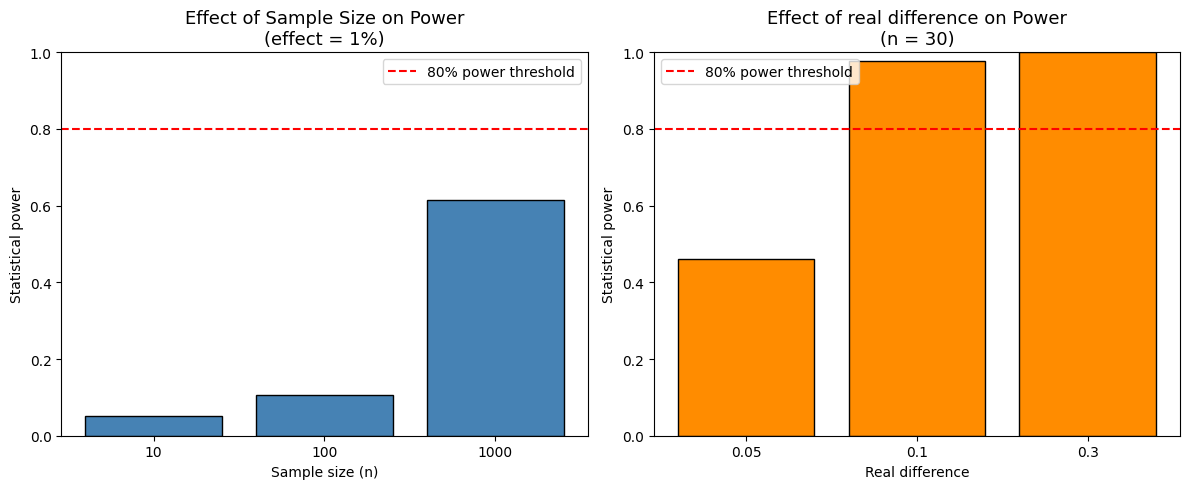

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: sample size effect 
axes[0].bar([str(n) for n in sizes], powers_size, color='steelblue', edgecolor='black')
axes[0].axhline(0.8, color='red', linestyle='--', label='80% power threshold')
axes[0].set_title('Effect of Sample Size on Power\n(effect = 1%)', fontsize=13)
axes[0].set_xlabel('Sample size (n)')
axes[0].set_ylabel('Statistical power')
axes[0].set_ylim(0, 1)
axes[0].legend()

# Right: effect size impact 
axes[1].bar([str(n) for n in diffs], powers_diff, color='darkorange', edgecolor='black')
axes[1].axhline(0.8, color='red', linestyle='--', label='80% power threshold')
axes[1].set_title('Effect of real difference on Power\n(n = 30)', fontsize=13)
axes[1].set_xlabel('Real difference')
axes[1].set_ylabel('Statistical power')
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.tight_layout()
plt.show()